In [3]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt 
%matplotlib inline
import datetime


from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

In [22]:
import kagglehub
path = kagglehub.dataset_download("umerhaddii/apple-stock-data-2025")
print("Path to dataset files:", path)

import os
os.listdir(path)

Path to dataset files: /Users/1an/.cache/kagglehub/datasets/umerhaddii/apple-stock-data-2025/versions/1


['apple_stock.csv']

In [53]:
data = pd.read_csv(path + '/apple_stock.csv')
print(data.shape)
data.head()
type(data)

(11107, 7)


pandas.DataFrame

In [55]:
data.rename(columns={'Unnamed: 0': 'Date'}, inplace=True)
data['Date'] = pd.to_datetime(data['Date'])
data = data[data['Date'].dt.year >= 2006]
data = data.reset_index(drop=True)
data.columns = [col.lower().replace(' ', '_') for col in data.columns]
data.head()


,date,adj_close,close,high,low,open,volume
0,2006-01-03,2.251970,2.669643,2.669643,2.580357,2.585000,807234400
1,2006-01-04,2.258598,2.677500,2.713571,2.660714,2.683214,619603600
2,2006-01-05,2.240824,2.656429,2.675000,2.633929,2.672500,449422400
3,2006-01-06,2.298666,2.725000,2.739286,2.662500,2.687500,704457600
4,2006-01-09,2.291134,2.716071,2.757143,2.705000,2.740357,675040800


In [56]:
price = data['adj_close']
price

0         2.251970
1         2.258598
2         2.240824
3         2.298666
4         2.291134
           ...    
4778    255.589996
4779    252.199997
4780    250.419998
4781    243.850006
4782    243.860001
Name: adj_close, Length: 4783, dtype: float64

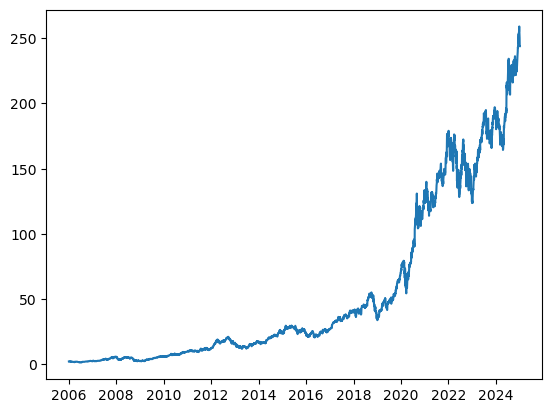

In [57]:
plt.plot(data.date, data.adj_close)
plt.show()